# Ablation — 2D Matrix Quantization Bitwidth

Sweeps `matrix_quant_bits` ∈ {16, 8, 6, 4} (1 seed).

| config | meaning |
|---|---|
| `bits = 16` | no quantization — 2D matrices stored as fp16 (passthrough) |
| `bits = 8` | baseline int8 per-row quantization (±127) |
| `bits = 6` | int6 per-row quantization (±31) stored in int8 container |
| `bits = 4` | int4 per-row quantization (±7) stored in int8 container |

This ablation isolates the effect of quantization bitwidth on the **2D weight matrices** (attention Q/K/V/proj and MLP fc/proj), which make up the bulk of the model's parameters. All other quantization settings remain unchanged: control tensors stay in fp32, small tensors (<65 536 elements) stay in fp16. Training is identical across all configs — only the post-training quantization changes.

The key metrics are:
- **Round-trip BPB** (`final_val_bpb`): the BPB after quantize → compress → decompress → dequantize → evaluate.
- **Delta (Δ)**: the BPB increase caused by quantization, i.e. `round_trip_bpb − fp32_bpb`.
- **Compressed file size**: the zlib-compressed model artifact in bytes.

Since training is the same for all runs, differences in BPB come entirely from quantization damage.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib
import utils as utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

# Human-readable labels and display order
BITS_ORDER  = [16, 8, 6, 4]
BITS_LABELS = {
    16: "fp16 (no quant)",
    8:  "int8 (baseline)",
    6:  "int6",
    4:  "int4",
}
BITS_COLORS = {b: PALETTE[i] for i, b in enumerate(BITS_ORDER)}

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\matte\_netrc.


## Original Baseline (3 seeds, reference)

In [2]:
BASELINE_PREFIX = "golf_baseline_matteo_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN = df_base["final_val_bpb"].mean()
BASE_BPB_STD  = df_base["final_val_bpb"].std()

print("=" * 50)
print("ORIGINAL BASELINE  (3 seeds)")
print("=" * 50)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print("=" * 50)

ORIGINAL BASELINE  (3 seeds)
 seed  final_val_bpb  final_val_loss
   42       1.311341        2.214145
   42       1.311540        2.214480
  123       1.308945        2.210099
  123       1.308339        2.209076
 1337            NaN             NaN
 1337       1.310012        2.211900
 1337       1.310216        2.212246

final_val_bpb : 1.3101 ± 0.0013


## Ablation — 2D Matrix Quantization Bitwidth

In [3]:
ABL_PREFIX = "golf_2d_matrices_quantization_ablation"

abl_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL_PREFIX}"}},
))

rows = []
for run in abl_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", 8)

    # fp32 BPB: last val_bpb logged during training (before quantization)
    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    rows.append({
        "run_name":          run.name,
        "matrix_quant_bits": bits,
        "label":             BITS_LABELS.get(bits, str(bits)),
        "seed":              cfg.get("seed"),
        "fp32_val_bpb":      fp32_bpb,
        "final_val_bpb":     s.get("final_val_bpb"),
        "final_val_loss":    s.get("final_val_loss"),
        "quant_file_bytes":  s.get("quant_file_bytes"),
    })

df = (
    pd.DataFrame(rows)
    .assign(bits_order=lambda d: d["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}))
    .sort_values("bits_order")
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

# Compute delta (quantization damage)
df["delta_bpb"] = df["final_val_bpb"] - df["fp32_val_bpb"]

df_plot = (
    df.groupby("matrix_quant_bits")
    .agg(
        n_runs=("run_name", "count"),
        fp32_val_bpb_median=("fp32_val_bpb", "median"),
        fp32_val_bpb_q25=("fp32_val_bpb", lambda s: s.quantile(0.25)),
        fp32_val_bpb_q75=("fp32_val_bpb", lambda s: s.quantile(0.75)),
        final_val_bpb_median=("final_val_bpb", "median"),
        final_val_bpb_q25=("final_val_bpb", lambda s: s.quantile(0.25)),
        final_val_bpb_q75=("final_val_bpb", lambda s: s.quantile(0.75)),
        delta_bpb_median=("delta_bpb", "median"),
        delta_bpb_q25=("delta_bpb", lambda s: s.quantile(0.25)),
        delta_bpb_q75=("delta_bpb", lambda s: s.quantile(0.75)),
        quant_file_bytes_median=("quant_file_bytes", "median"),
        quant_file_bytes_q25=("quant_file_bytes", lambda s: s.quantile(0.25)),
        quant_file_bytes_q75=("quant_file_bytes", lambda s: s.quantile(0.75)),
    )
    .reset_index()
    .assign(label=lambda d: d["matrix_quant_bits"].map(BITS_LABELS))
)

df_plot

,matrix_quant_bits,n_runs,fp32_val_bpb_median,fp32_val_bpb_q25,fp32_val_bpb_q75,final_val_bpb_median,final_val_bpb_q25,final_val_bpb_q75,delta_bpb_median,delta_bpb_q25,delta_bpb_q75,quant_file_bytes_median,quant_file_bytes_q25,quant_file_bytes_q75,label
0,4,3,1.305906,1.305766,1.306441,2.245742,2.230646,2.252598,0.940116,0.924345,0.946832,7846052.0,7844017.0,7847021.5,int4
1,6,3,1.306064,1.305524,1.306522,1.364526,1.363507,1.365434,0.057545,0.056985,0.059452,11903307.0,11899702.5,11904365.5,int6
2,8,3,1.306432,1.306004,1.307151,1.310132,1.309636,1.310895,0.003700,0.003631,0.003743,15775590.0,15772238.0,15782993.5,int8 (baseline)


### Compressed file size vs bitwidth

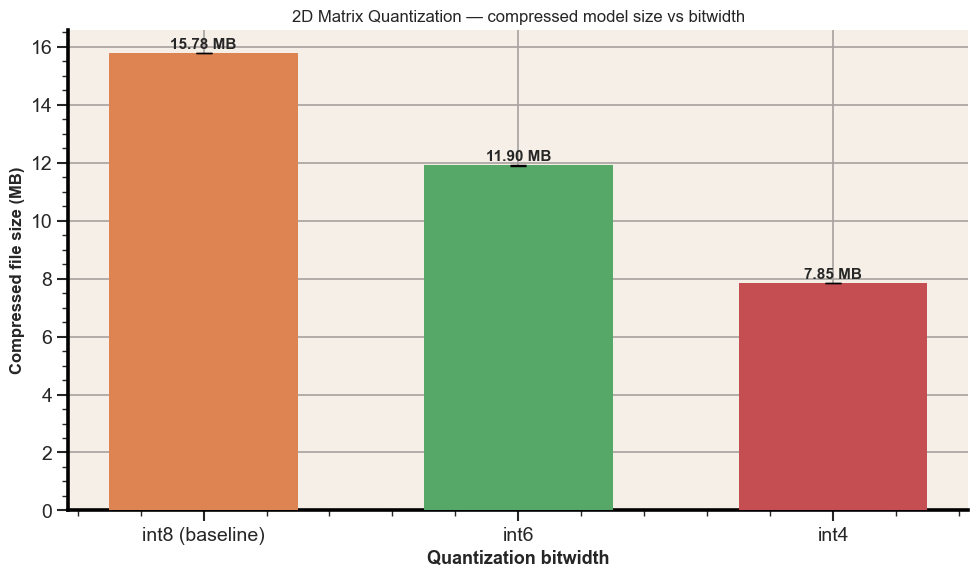

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = df_plot[df_plot["matrix_quant_bits"].isin(BITS_ORDER)].copy()
plot_df["bits_order"] = plot_df["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)})
plot_df = plot_df.sort_values("bits_order")

bits_vals = plot_df["matrix_quant_bits"].tolist()
size_mb   = (plot_df["quant_file_bytes_median"] / 1e6).tolist()
size_q25  = (plot_df["quant_file_bytes_q25"] / 1e6).tolist()
size_q75  = (plot_df["quant_file_bytes_q75"] / 1e6).tolist()
size_yerr = np.vstack([
    np.array(size_mb) - np.array(size_q25),
    np.array(size_q75) - np.array(size_mb),
])
colors    = [BITS_COLORS[b] for b in bits_vals]

ax.bar(range(len(bits_vals)), size_mb, color=colors, width=0.6, zorder=3,
       yerr=size_yerr, capsize=6, ecolor="black")

for i, (b, mb) in enumerate(zip(bits_vals, size_mb)):
    ax.text(i, size_q75[i] + 0.05, f"{mb:.2f} MB", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

# baseline int8 reference line
if 8 in plot_df["matrix_quant_bits"].values:
    int8_mb = plot_df.loc[plot_df["matrix_quant_bits"] == 8, "quant_file_bytes_median"].iloc[0] / 1e6

ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("2D Matrix Quantization — compressed model size vs bitwidth", fontsize=12)
plt.tight_layout(pad=1.5)
plt.show()

### Round-trip BPB vs bitwidth

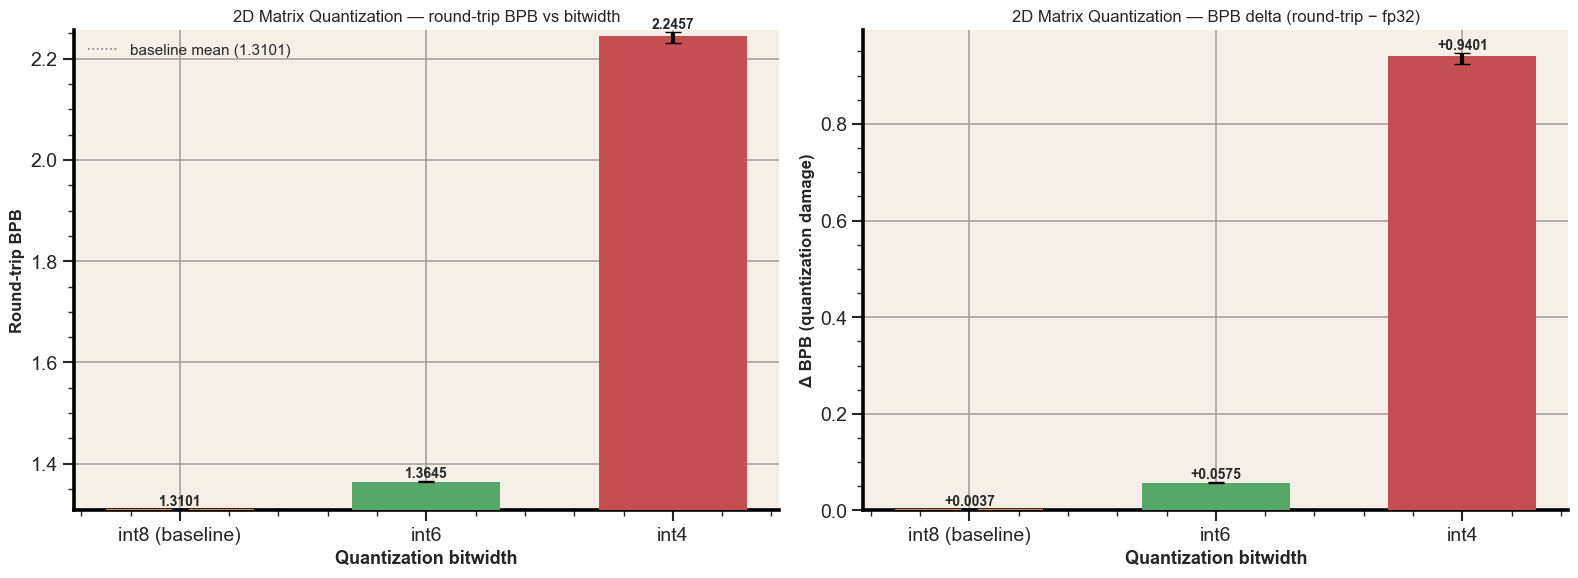

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = df_plot[df_plot["matrix_quant_bits"].isin(BITS_ORDER)].copy()
plot_df["bits_order"] = plot_df["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)})
plot_df = plot_df.sort_values("bits_order")

bits_vals = plot_df["matrix_quant_bits"].tolist()
roundtrip = plot_df["final_val_bpb_median"].tolist()
roundtrip_q25 = plot_df["final_val_bpb_q25"].tolist()
roundtrip_q75 = plot_df["final_val_bpb_q75"].tolist()
roundtrip_yerr = np.vstack([
    np.array(roundtrip) - np.array(roundtrip_q25),
    np.array(roundtrip_q75) - np.array(roundtrip),
])
deltas    = plot_df["delta_bpb_median"].tolist()
delta_q25 = plot_df["delta_bpb_q25"].tolist()
delta_q75 = plot_df["delta_bpb_q75"].tolist()
delta_yerr = np.vstack([
    np.array(deltas) - np.array(delta_q25),
    np.array(delta_q75) - np.array(deltas),
])
colors    = [BITS_COLORS[b] for b in bits_vals]

# --- Round-trip BPB ---
ax = axes[0]
ax.bar(range(len(bits_vals)), roundtrip, color=colors, width=0.6, zorder=3,
       yerr=roundtrip_yerr, capsize=6, ecolor="black")

for i, (b, bpb) in enumerate(zip(bits_vals, roundtrip)):
    ax.text(i, roundtrip_q75[i] + 0.0005, f"{bpb:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("2D Matrix Quantization — round-trip BPB vs bitwidth", fontsize=12)
ax.legend(fontsize=11)

# Tight y-axis around the data
ymin = min(roundtrip_q25) - 0.002
ymax = max(roundtrip_q75) + 0.004
ax.set_ylim(ymin, ymax)

# --- Delta (quantization damage) ---
ax = axes[1]
ax.bar(range(len(bits_vals)), deltas, color=colors, width=0.6, zorder=3,
       yerr=delta_yerr, capsize=6, ecolor="black")

for i, (b, d) in enumerate(zip(bits_vals, deltas)):
    ax.text(i, delta_q75[i] + 0.0003, f"{d:+.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Δ BPB (quantization damage)", fontsize=12)
ax.set_title("2D Matrix Quantization — BPB delta (round-trip − fp32)", fontsize=12)

plt.tight_layout(pad=1.5)
plt.show()

### Tradeoff: BPB vs compressed size

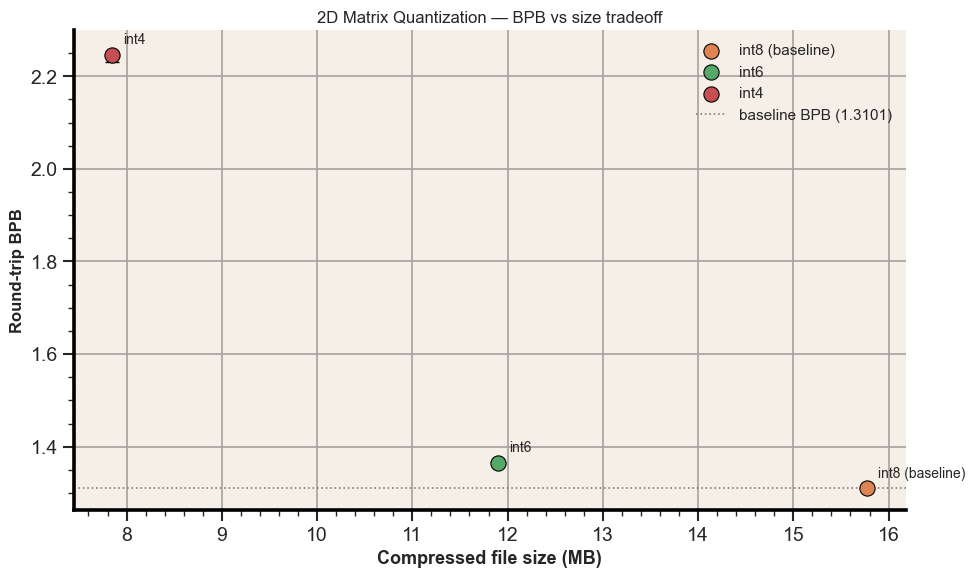

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = df_plot[df_plot["matrix_quant_bits"].isin(BITS_ORDER)].copy()
plot_df["bits_order"] = plot_df["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)})
plot_df = plot_df.sort_values("bits_order")

for b in plot_df["matrix_quant_bits"]:
    row = plot_df[plot_df["matrix_quant_bits"] == b].iloc[0]
    x = row["quant_file_bytes_median"] / 1e6
    y = row["final_val_bpb_median"]
    xerr = np.array([[x - row["quant_file_bytes_q25"] / 1e6], [row["quant_file_bytes_q75"] / 1e6 - x]])
    yerr = np.array([[y - row["final_val_bpb_q25"]], [row["final_val_bpb_q75"] - y]])
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="none", color="black", capsize=5, zorder=4)
    ax.scatter(x, y,
               color=BITS_COLORS[b], s=120, zorder=5,
               label=BITS_LABELS[b], edgecolors="black", linewidth=0.8)
    ax.annotate(BITS_LABELS[b],
                (x, y),
                textcoords="offset points", xytext=(8, 8), fontsize=10)

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline BPB ({BASE_BPB_MEAN:.4f})")

ax.set_xlabel("Compressed file size (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("2D Matrix Quantization — BPB vs size tradeoff", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### Summary table

In [7]:
rows_summary = [{
    "config":          "Original baseline (3 seeds)",
    "val_bpb":         BASE_BPB_MEAN,
    "val_bpb_std":     BASE_BPB_STD,
    "Δ vs int8":       0.0,
    "file_size_MB":    float("nan"),
}]

int8_bpb = plot_df.loc[plot_df["matrix_quant_bits"] == 8, "final_val_bpb_median"].iloc[0] \
           if 8 in plot_df["matrix_quant_bits"].values else BASE_BPB_MEAN

for b in BITS_ORDER:
    sub = plot_df[plot_df["matrix_quant_bits"] == b]
    if sub.empty:
        continue
    row = sub.iloc[0]
    rows_summary.append({
        "config":        BITS_LABELS[b],
        "val_bpb":       row["final_val_bpb_median"],
        "val_bpb_std":   float("nan"),
        "Δ vs int8":     row["final_val_bpb_median"] - int8_bpb,
        "file_size_MB":  row["quant_file_bytes_median"] / 1e6,
    })

df_summary = pd.DataFrame(rows_summary)
df_summary["val_bpb"]      = df_summary["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary["val_bpb_std"]  = df_summary["val_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_summary["Δ vs int8"]    = df_summary["Δ vs int8"].map(lambda x: f"{x:+.4f}")
df_summary["file_size_MB"] = df_summary["file_size_MB"].map(lambda x: f"{x:.2f}" if not np.isnan(x) else "—")

print(df_summary.to_string(index=False))

# Conclusion
if not plot_df.empty:
    best = plot_df.loc[plot_df["final_val_bpb_median"].idxmin()]
    print(f"\nBest round-trip BPB: {best['final_val_bpb_median']:.4f} "
          f"at {BITS_LABELS[best['matrix_quant_bits']]} "
          f"({best['quant_file_bytes_median'] / 1e6:.2f} MB)")
    print(f"Smallest file: "
          f"{plot_df.loc[plot_df['quant_file_bytes_median'].idxmin(), 'quant_file_bytes_median'] / 1e6:.2f} MB "
          f"at {BITS_LABELS[plot_df.loc[plot_df['quant_file_bytes_median'].idxmin(), 'matrix_quant_bits']]}")

                     config val_bpb val_bpb_std Δ vs int8 file_size_MB
Original baseline (3 seeds)  1.3101     ±0.0013   +0.0000            —
            int8 (baseline)  1.3101           —   +0.0000        15.78
                       int6  1.3645           —   +0.0544        11.90
                       int4  2.2457           —   +0.9356         7.85

Best round-trip BPB: 1.3101 at int8 (baseline) (15.78 MB)
Smallest file: 7.85 MB at int4
